## Conectarse a RDS PostgreSQL

In [1]:
import boto3
import json
from sqlalchemy import create_engine

# Recuperar credenciales desde Secrets Manager
client = boto3.client("secretsmanager", region_name="us-east-1")
secret = client.get_secret_value(SecretId="itam/rds/flights/credentials")
creds = json.loads(secret["SecretString"])

# Endpoint primario — para crear tablas e insertar datos
RDS_ENDPOINT = "itam-northwind-561137843164.cw5yuskyg5vm.us-east-1.rds.amazonaws.com"

engine = create_engine(
    f"postgresql+psycopg2://{creds['username']}:{creds['password']}@{RDS_ENDPOINT}:{creds['port']}/{creds['dbname']}"
)

with engine.connect() as conn:
    print("✓ Conexión exitosa a RDS PostgreSQL")

✓ Conexión exitosa a RDS PostgreSQL


## Definir el schema y crear las tres tablas

In [2]:
from sqlalchemy.orm import DeclarativeBase, mapped_column, Mapped
from sqlalchemy import String, Integer, Float, ForeignKey
from typing import Optional

class Base(DeclarativeBase):
    pass

class Airline(Base):
    __tablename__ = "airlines"
    iata_code:  Mapped[str]             = mapped_column(String(10),  primary_key=True)
    airline:    Mapped[str]             = mapped_column(String(100))

class Airport(Base):
    __tablename__ = "airports"
    iata_code:  Mapped[str]             = mapped_column(String(10),  primary_key=True)
    airport:    Mapped[str]             = mapped_column(String(200))
    city:       Mapped[Optional[str]]   = mapped_column(String(100))
    state:      Mapped[Optional[str]]   = mapped_column(String(50))
    country:    Mapped[Optional[str]]   = mapped_column(String(50))
    latitude:   Mapped[Optional[float]] = mapped_column(Float)
    longitude:  Mapped[Optional[float]] = mapped_column(Float)

class Flight(Base):
    __tablename__ = "flights"
    id:                  Mapped[int]             = mapped_column(Integer, primary_key=True, autoincrement=True)
    year:                Mapped[int]             = mapped_column(Integer)
    month:               Mapped[int]             = mapped_column(Integer)
    day:                 Mapped[int]             = mapped_column(Integer)
    airline:             Mapped[str]             = mapped_column(String(10), ForeignKey("airlines.iata_code"))
    origin_airport:      Mapped[str]             = mapped_column(String(10), ForeignKey("airports.iata_code"))
    destination_airport: Mapped[str]             = mapped_column(String(10), ForeignKey("airports.iata_code"))
    departure_delay:     Mapped[Optional[float]] = mapped_column(Float)
    arrival_delay:       Mapped[Optional[float]] = mapped_column(Float)
    cancelled:           Mapped[int]             = mapped_column(Integer)
    cancellation_reason: Mapped[Optional[str]]   = mapped_column(String(5))
    distance:            Mapped[Optional[float]] = mapped_column(Float)
    air_system_delay:    Mapped[Optional[float]] = mapped_column(Float)
    airline_delay:       Mapped[Optional[float]] = mapped_column(Float)
    weather_delay:       Mapped[Optional[float]] = mapped_column(Float)
    late_aircraft_delay: Mapped[Optional[float]] = mapped_column(Float)
    security_delay:      Mapped[Optional[float]] = mapped_column(Float)

# Idempotencia
Base.metadata.drop_all(engine)
Base.metadata.create_all(engine)
print("✓ Schema creado en PostgreSQL")

✓ Schema creado en PostgreSQL


## Insertar datos

In [5]:
import pandas as pd
from sqlalchemy.orm import Session
from sqlalchemy import insert


def load_csv(session, model, df):
    df = df.rename(columns=str.lower)
    records = [
        {k: None if pd.isnull(v) else v for k, v in row.items()}
        for row in df.to_dict(orient="records")
    ]
    session.execute(insert(model), records)
    print(f"✓ {model.__tablename__}: {len(records):,} filas cargadas")

df_airlines = pd.read_csv("data/flights/airlines.csv")
df_airports = pd.read_csv("data/flights/airports.csv")
df_flights  = pd.read_csv("data/flights/flights.csv", nrows=500_000)

with Session(engine) as session:
    load_csv(session, Airline, df_airlines)
    load_csv(session, Airport, df_airports)
    load_csv(session, Flight,  df_flights)
    session.commit()
    print("✓ Carga completa")

✓ airlines: 14 filas cargadas
✓ airports: 322 filas cargadas
✓ flights: 500,000 filas cargadas
✓ Carga completa


## Consultas con awswrangler

### Conectarse a la réplica

In [6]:
# Read Replica — para queries analíticas
REPLICA_ENDPOINT = "itam-northwind-replica-561137843164.cw5yuskyg5vm.us-east-1.rds.amazonaws.com"

engine_replica = create_engine(
    f"postgresql+psycopg2://{creds['username']}:{creds['password']}@{REPLICA_ENDPOINT}:{creds['port']}/{creds['dbname']}"
)

with engine_replica.connect() as conn:
    print("✓ Conexión exitosa a Read Replica")

✓ Conexión exitosa a Read Replica


### Repetir las 8 preguntas con queries SQL

,origin_airport,destination_airport,total_vuelos
0,LAX,JFK,1218
1,JFK,LAX,1217
2,SFO,LAX,1186
3,LAX,SFO,1172
4,LAS,LAX,1018
5,LAX,LAS,987
6,LGA,ORD,917
7,ORD,LGA,908
8,HNL,OGG,874
9,OGG,HNL,873


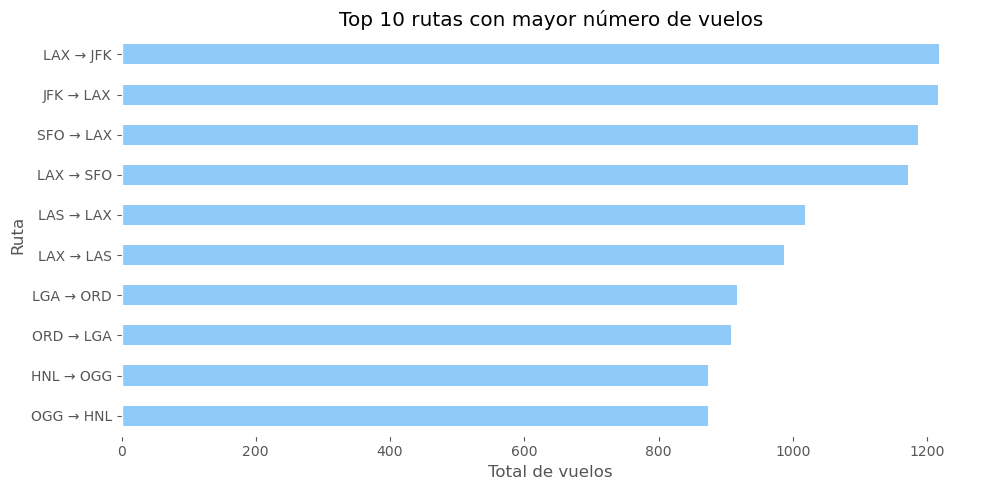

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# P1 — Top 10 rutas con mayor número de vuelos
query_p1 = """
SELECT 
    origin_airport,
    destination_airport,
    COUNT(*) AS total_vuelos
FROM flights
GROUP BY origin_airport, destination_airport
ORDER BY total_vuelos DESC
LIMIT 10;
"""

df_p1 = pd.read_sql(query_p1, engine_replica)
display(df_p1)

# Visualización
df_p1["ruta"] = df_p1["origin_airport"] + " → " + df_p1["destination_airport"]

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")
df_p1.plot(kind="barh", x="ruta", y="total_vuelos", legend=False, color="#90caf9", ax=ax)
ax.set_title("Top 10 rutas con mayor número de vuelos")
ax.set_xlabel("Total de vuelos")
ax.set_ylabel("Ruta")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

,airline,total_vuelos,total_cancelados,pct_cancelados
0,MQ,31896,3136,9.83
1,B6,23062,1479,6.41
2,EV,52965,2523,4.76
3,US,35591,1268,3.56
4,UA,40873,1424,3.48


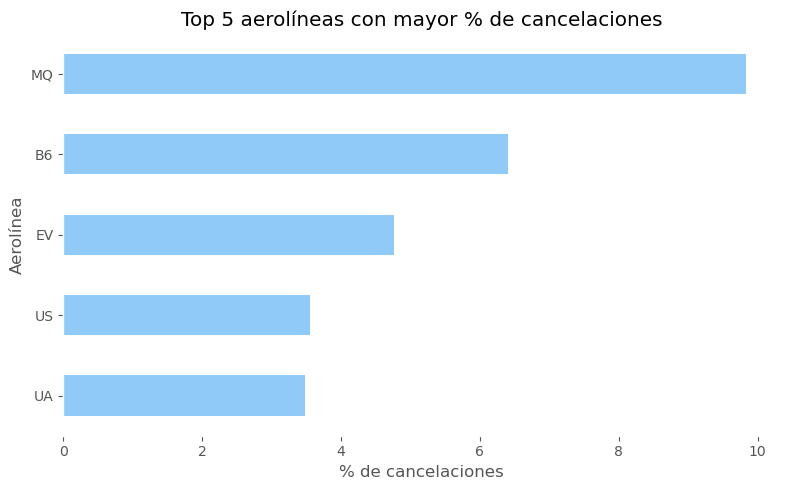

In [13]:
# P2 — Top 5 aerolíneas con mayor porcentaje de vuelos cancelados
query_p2 = """
SELECT 
    airline,
    COUNT(*) AS total_vuelos,
    SUM(cancelled) AS total_cancelados,
    ROUND(SUM(cancelled)::numeric / COUNT(*) * 100, 2) AS pct_cancelados
FROM flights
GROUP BY airline
ORDER BY pct_cancelados DESC
LIMIT 5;
"""

df_p2 = pd.read_sql(query_p2, engine_replica)
display(df_p2)

# Visualización
fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")
ax.set_facecolor("white")
df_p2.plot(kind="barh", x="airline", y="pct_cancelados", legend=False, color="#90caf9", ax=ax)
ax.set_title("Top 5 aerolíneas con mayor % de cancelaciones")
ax.set_xlabel("% de cancelaciones")
ax.set_ylabel("Aerolínea")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

,cancellation_reason,total_cancelados
0,A,3230
1,B,10630
2,C,2962
3,D,2


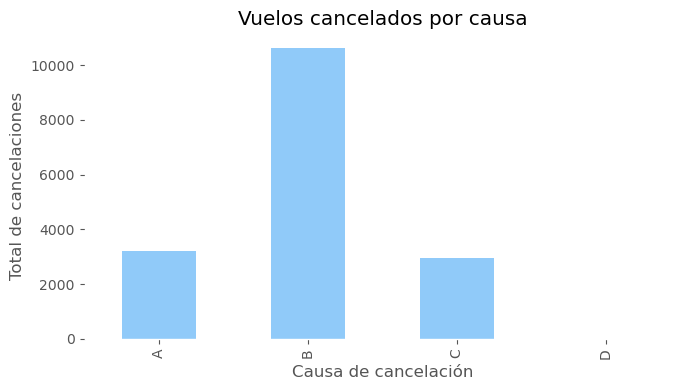

In [15]:
# P3 — Vuelos cancelados por causa
query_p3 = """
SELECT 
    cancellation_reason,
    COUNT(*) AS total_cancelados
FROM flights
WHERE cancellation_reason IS NOT NULL
GROUP BY cancellation_reason;
"""

df_p3 = pd.read_sql(query_p3, engine_replica)
display(df_p3)

# Visualización
fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
df_p3.plot(kind="bar", x="cancellation_reason", y="total_cancelados", legend=False, color="#90caf9", ax=ax)
ax.set_title("Vuelos cancelados por causa")
ax.set_xlabel("Causa de cancelación")
ax.set_ylabel("Total de cancelaciones")
plt.tight_layout()
plt.show()

,month,promedio_retraso
0,1,32.571225
1,2,42.306487


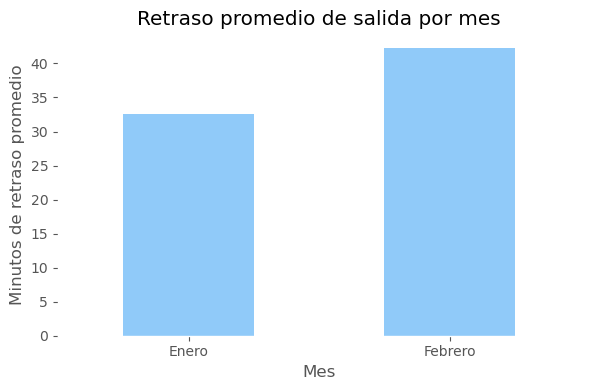

In [17]:
# P4 — Retraso promedio de salida por mes
query_p4 = """
SELECT 
    month,
    AVG(departure_delay) AS promedio_retraso
FROM flights
WHERE cancelled = 0 AND departure_delay > 0
GROUP BY month
ORDER BY month;
"""

df_p4 = pd.read_sql(query_p4, engine_replica)
display(df_p4)

# Visualización
meses = {1: "Enero", 2: "Febrero"}
df_p4["mes_nombre"] = df_p4["month"].map(meses)

fig, ax = plt.subplots(figsize=(6, 4), facecolor="white")
ax.set_facecolor("white")
df_p4.plot(kind="bar", x="mes_nombre", y="promedio_retraso", legend=False, color="#90caf9", ax=ax)
ax.set_title("Retraso promedio de salida por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Minutos de retraso promedio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,origin_airport,total_minutos_clima
0,ORD,102749.0
1,JFK,20542.0
2,LGA,13620.0
3,ATL,12562.0
4,DTW,12361.0
5,BOS,11361.0
6,DEN,8359.0
7,DCA,8188.0
8,PHX,7878.0
9,DFW,6870.0


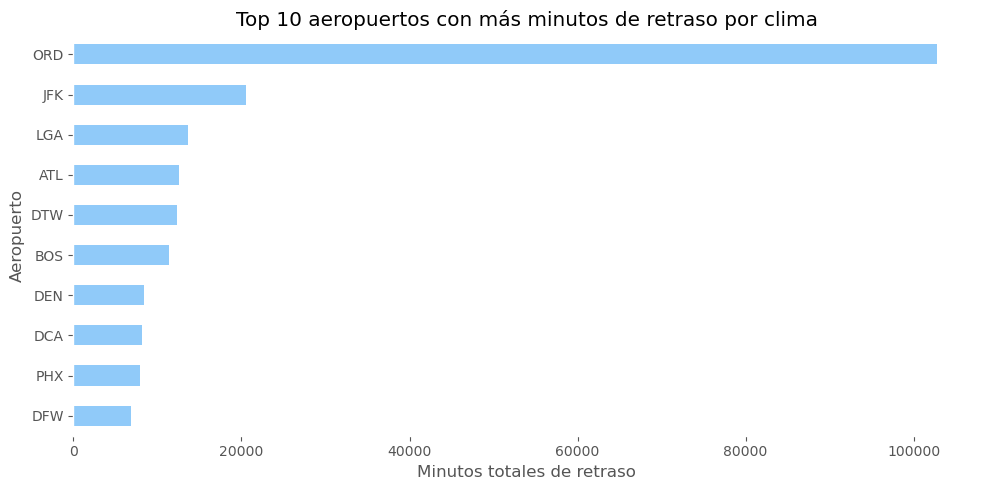

In [18]:
# P5 — Top 10 aeropuertos con más minutos de retraso por clima
query_p5 = """
SELECT 
    origin_airport,
    SUM(weather_delay) AS total_minutos_clima
FROM flights
WHERE weather_delay > 0
GROUP BY origin_airport
ORDER BY total_minutos_clima DESC
LIMIT 10;
"""

df_p5 = pd.read_sql(query_p5, engine_replica)
display(df_p5)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")
df_p5.plot(kind="barh", x="origin_airport", y="total_minutos_clima", legend=False, color="#90caf9", ax=ax)
ax.set_title("Top 10 aeropuertos con más minutos de retraso por clima")
ax.set_xlabel("Minutos totales de retraso")
ax.set_ylabel("Aeropuerto")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

,airline,origin_airport,destination_airport,arrival_delay,rank
0,AA,BHM,DFW,1971.0,1
1,AS,LAX,SEA,451.0,1
2,B6,MSY,JFK,502.0,1
3,DL,MIA,MSP,1174.0,1
4,EV,SHV,DFW,723.0,1
5,F9,ORD,MIA,686.0,1
6,HA,JFK,HNL,1013.0,1
7,MQ,CLL,DFW,788.0,1
8,NK,TPA,ORD,570.0,1
9,OO,CHO,ORD,953.0,1


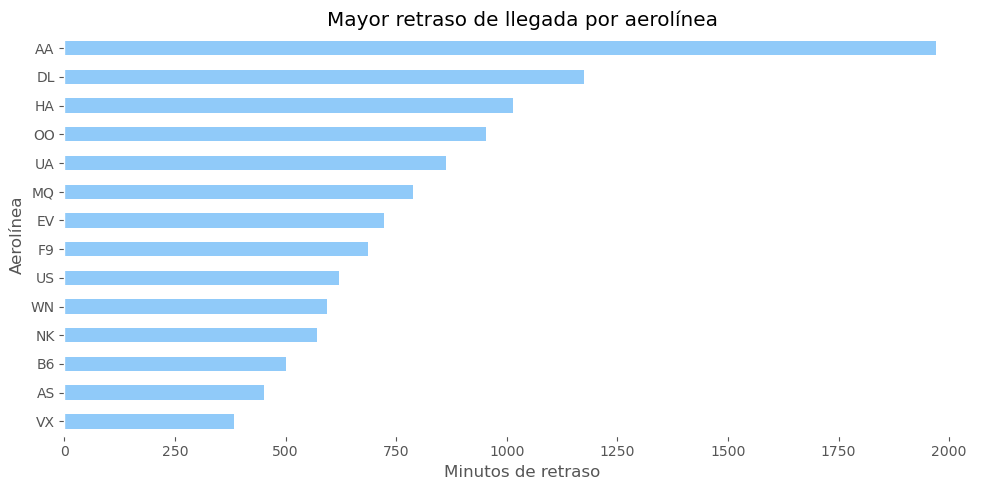

In [20]:
# W1 — Vuelo con mayor retraso de llegada por aerolínea
query_w1 = """
SELECT *
FROM (
    SELECT 
        airline,
        origin_airport,
        destination_airport,
        arrival_delay,
        RANK() OVER (PARTITION BY airline ORDER BY arrival_delay DESC NULLS LAST) AS rank
    FROM flights
    WHERE cancelled = 0
) ranked
WHERE rank = 1;
"""

df_w1 = pd.read_sql(query_w1, engine_replica)
display(df_w1)

# Visualización
df_w1_sorted = df_w1.sort_values("arrival_delay", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")
df_w1_sorted.plot(kind="barh", x="airline", y="arrival_delay", legend=False, color="#90caf9", ax=ax)
ax.set_title("Mayor retraso de llegada por aerolínea")
ax.set_xlabel("Minutos de retraso")
ax.set_ylabel("Aerolínea")
plt.tight_layout()
plt.show()

,month,total_vuelos,vuelos_mes_anterior,variacion,variacion_pct
0,1,469968,<NA>,<NA>,NaN
1,2,429191,469968,-40777,-8.68
2,3,504312,429191,75121,17.50
3,4,485151,504312,-19161,-3.80
4,5,496993,485151,11842,2.44
5,6,503897,496993,6904,1.39
6,7,520718,503897,16821,3.34
7,8,510536,520718,-10182,-1.96
8,9,464946,510536,-45590,-8.93
9,10,486165,464946,21219,4.56


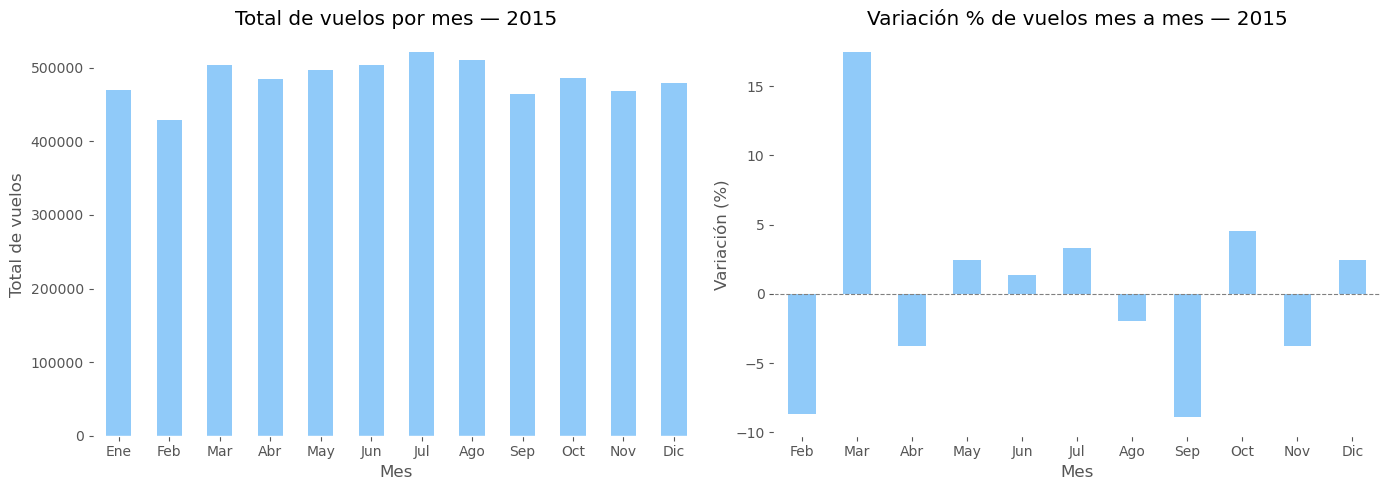

In [23]:
import awswrangler as wr

# W2 — Variación mes a mes en el total de vuelos (desde Silver en Athena)
query_w2 = """
SELECT
    month,
    SUM(total_flights) AS total_vuelos,
    LAG(SUM(total_flights)) OVER (ORDER BY month) AS vuelos_mes_anterior,
    SUM(total_flights) - LAG(SUM(total_flights)) OVER (ORDER BY month) AS variacion,
    ROUND(
        100.0 * (SUM(total_flights) - LAG(SUM(total_flights)) OVER (ORDER BY month))
        / NULLIF(LAG(SUM(total_flights)) OVER (ORDER BY month), 0), 2
    ) AS variacion_pct
FROM flights_silver.flights_monthly
GROUP BY month
ORDER BY month
"""

df_w2 = wr.athena.read_sql_query(query_w2, database="flights_silver", ctas_approach=False)
display(df_w2)

# Visualización
meses = {1:"Ene", 2:"Feb", 3:"Mar", 4:"Abr", 5:"May", 6:"Jun",
         7:"Jul", 8:"Ago", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dic"}
df_w2["mes_nombre"] = df_w2["month"].map(meses)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")

# Gráfica 1 — Total de vuelos
axes[0].set_facecolor("white")
df_w2.plot(kind="bar", x="mes_nombre", y="total_vuelos", legend=False, color="#90caf9", ax=axes[0])
axes[0].set_title("Total de vuelos por mes — 2015")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Total de vuelos")
axes[0].tick_params(axis="x", rotation=0)

# Gráfica 2 — Cambio porcentual
axes[1].set_facecolor("white")
df_w2.dropna(subset=["variacion_pct"]).plot(
    kind="bar", x="mes_nombre", y="variacion_pct", legend=False, color="#90caf9", ax=axes[1]
)
axes[1].set_title("Variación % de vuelos mes a mes — 2015")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Variación (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].axhline(y=0, color="gray", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

,row_num,id,airline,destination_airport,departure_delay
0,1,3202,OO,SEA,-13.0
1,2,13269,OO,MRY,-13.0
2,3,13861,UA,BOS,-11.0
3,4,12184,OO,OAK,-11.0
4,5,1741,OO,TUS,-10.0


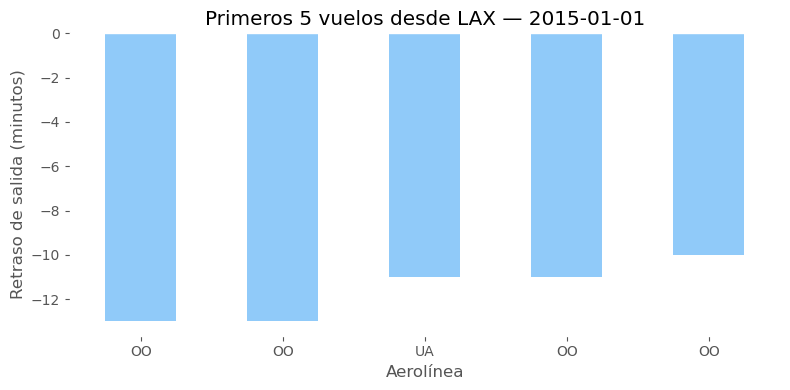

In [24]:
# W3 — Primeros 5 vuelos desde LAX el 2015-01-01
query_w3 = """
SELECT 
    ROW_NUMBER() OVER (
        PARTITION BY year, month, day, origin_airport 
        ORDER BY departure_delay ASC NULLS LAST
    ) AS row_num,
    id,
    airline,
    destination_airport,
    departure_delay
FROM flights
WHERE year = 2015 
  AND month = 1 
  AND day = 1 
  AND origin_airport = 'LAX'
LIMIT 5;
"""

df_w3 = pd.read_sql(query_w3, engine_replica)
display(df_w3)

# Visualización
fig, ax = plt.subplots(figsize=(8, 4), facecolor="white")
ax.set_facecolor("white")
df_w3.plot(kind="bar", x="airline", y="departure_delay", legend=False, color="#90caf9", ax=ax)
ax.set_title("Primeros 5 vuelos desde LAX — 2015-01-01")
ax.set_xlabel("Aerolínea")
ax.set_ylabel("Retraso de salida (minutos)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Análisis estadístico

El objetivo de este análisis es entender qué causas de retraso tienen mayor peso en el retraso total de llegada. No se trata de construir un modelo predictivo — es un análisis estadístico para cuantificar la contribución de cada variable.

## Leer los datos desde la capa Gold en Anthena

Por temas de memoria, no logro leer todos los datos (5.8 M), por eso la razón propongo la alternativa de tomar una muestra aleatoria del 10% de los datos y realizar la primera regresión con esos datos. 

In [3]:
# Regresión — leer datos desde Gold
import awswrangler as wr

df_reg = wr.athena.read_sql_query(
    """
    SELECT arrival_delay, departure_delay, distance,
           air_system_delay, airline_delay, weather_delay,
           late_aircraft_delay, security_delay
    FROM flights_gold.vuelos_analitica TABLESAMPLE BERNOULLI(10)
    WHERE cancelled = 0
      AND arrival_delay IS NOT NULL
    """,
    database="flights_gold",
    ctas_approach=False
)

print(f"Filas: {len(df_reg):,}")
df_reg.head()


2026-04-14 23:07:23,178	WARNING services.py:2070 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 409960448 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=0.75gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2026-04-14 23:07:24,474	INFO worker.py:1852 -- Started a local Ray instance.


Filas: 571,018


,arrival_delay,departure_delay,distance,air_system_delay,airline_delay,weather_delay,late_aircraft_delay,security_delay
0,-22.0,0.0,802,NaN,NaN,NaN,NaN,NaN
1,-14.0,-5.0,248,NaN,NaN,NaN,NaN,NaN
2,14.0,27.0,1199,NaN,NaN,NaN,NaN,NaN
3,-27.0,-5.0,196,NaN,NaN,NaN,NaN,NaN
4,-23.0,-6.0,1029,NaN,NaN,NaN,NaN,NaN


In [4]:
#Modelo con statsmodels 

import statsmodels.api as sm
import numpy as np

df_modelo = df_reg.copy()
df_modelo["distance"] = df_modelo["distance"].astype(float)
df_modelo = df_modelo.fillna(0)

features = ["departure_delay", "distance", "air_system_delay", 
            "airline_delay", "weather_delay", "late_aircraft_delay", "security_delay"]

X = sm.add_constant(df_modelo[features])
y = np.array(df_modelo["arrival_delay"])

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.943
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                 1.341e+06
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:07:54   Log-Likelihood:            -2.0929e+06
No. Observations:              571018   AIC:                         4.186e+06
Df Residuals:                  571010   BIC:                         4.186e+06
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -4.9516    

**Interpretación**

Es evidente la multicolinealidad al ver el número de condición tan alto y que los coeficientes son sospechosamente parecidos. Además de que la R2 también está demasiado alta y los intervalos son sumamente estrechos. 

### Visualización 1

Coeficientes con intervalos de confianza — gráfica de barras horizontal con los coeficientes de cada feature y sus intervalos de confianza al 95%. ¿Qué causa de retraso tiene el mayor impacto? ¿Cuál el menor?

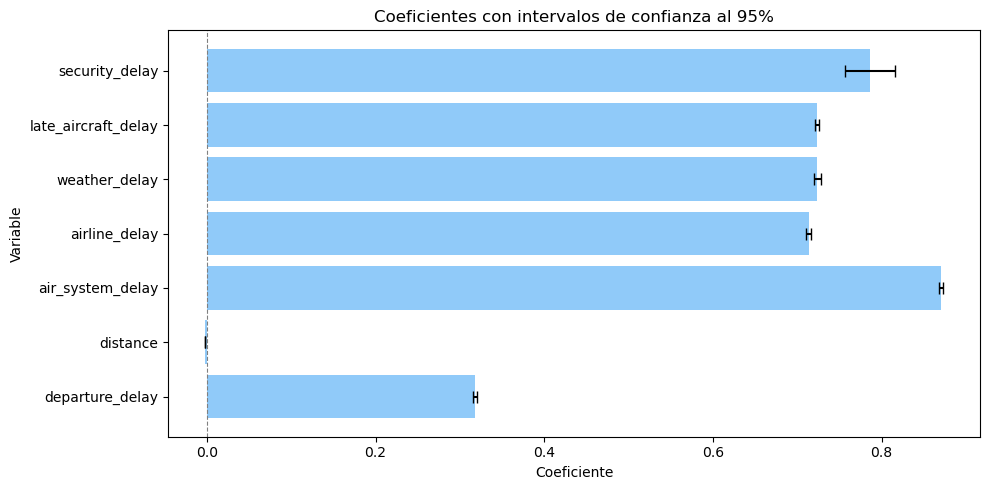

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Extraer coeficientes e intervalos de confianza
coef = modelo.params[1:]  # excluir constante
conf = modelo.conf_int()[1:]  # excluir constante
errores = np.array([coef - conf[0], conf[1] - coef])

fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")
ax.barh(coef.index, coef.values, xerr=errores, color="#90caf9", capsize=4)
ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Coeficientes con intervalos de confianza al 95%")
ax.set_xlabel("Coeficiente")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

**Respuestas**

Recordando que en las regresiones lineales, los coeficientes me hablan del aumento de la variable objetivo (arrival_delay), dado un aumento en la variable explicativa de interés. Aquella que tenga el coeficiente mayor, es la que tiene mayor impacto y viendo la gráfica sería "air_system_delay". 
La variable con menor impacto es "distance", que inclusive tiene un efecto negativo, sin embargo es un impacto prácticamente nulo. 

### Visualización 2

Valores predichos vs. valores reales — scatter plot de ŷ (eje x) contra y (eje y). En un modelo perfecto todos los puntos caen sobre la línea diagonal y = x. ¿Qué tan bien se alinean?

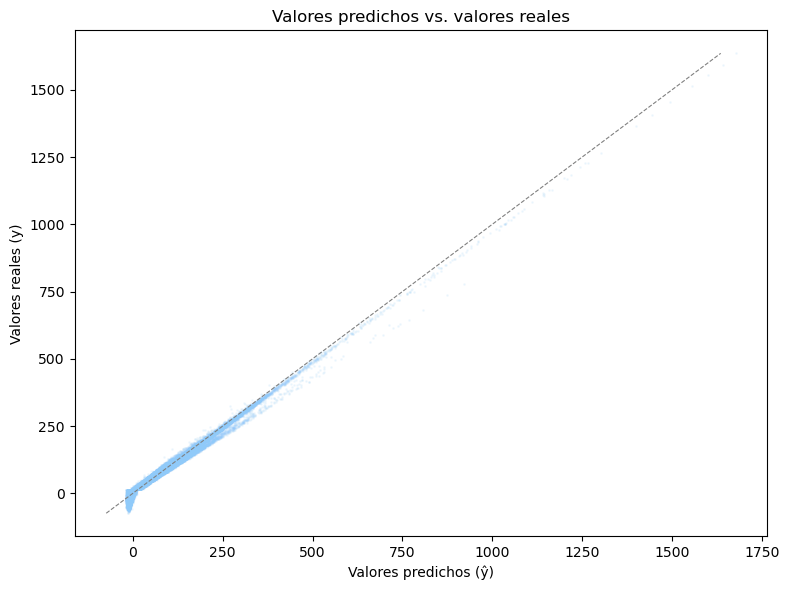

In [6]:
y_pred = modelo.fittedvalues

fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")
ax.scatter(y_pred, y, alpha=0.1, s=1, color="#90caf9")
ax.plot([y.min(), y.max()], [y.min(), y.max()], color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Valores predichos vs. valores reales")
ax.set_xlabel("Valores predichos (ŷ)")
ax.set_ylabel("Valores reales (y)")
plt.tight_layout()
plt.show()

**Respuestas**

Vemos que en general los resultados están bastante bien ajustados a la línea, casi haciendo una línea recta perfecta. Aunque hay valores que salen, en realidad, siguen estando bastante pegados a la recta.

### Visualización 3 

Residuos vs. valores predichos — scatter plot de los residuos (y - ŷ) contra los valores predichos ŷ. En un modelo bien especificado, los residuos deben estar distribuidos aleatoriamente alrededor de cero sin ningún patrón. ¿Identificas alguna estructura?

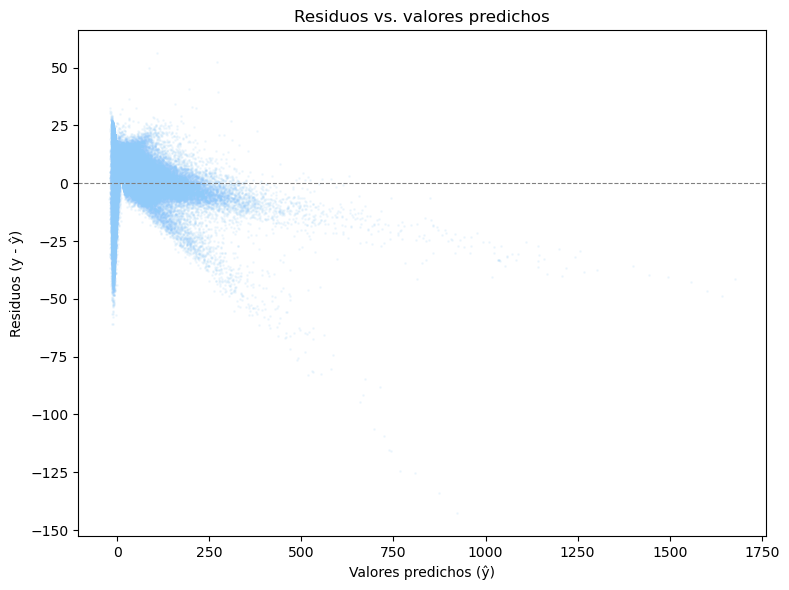

In [7]:
residuos = modelo.resid

fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")
ax.scatter(y_pred, residuos, alpha=0.1, s=1, color="#90caf9")
ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Residuos vs. valores predichos")
ax.set_xlabel("Valores predichos (ŷ)")
ax.set_ylabel("Residuos (y - ŷ)")
plt.tight_layout()
plt.show()

**Respuesta**

Lamentablemente sí hay una tendencia y es que tiene una forma de "K" o "V" y significa que la varianza de los residuos no es constante. Esto me habla de que la regresión lineal no está capturando la relación entre las variables 


### Visualización 4 

Compara la distribución de los residuos contra una normal teórica. Una desviación pronunciada en las colas indica que los residuos no son normales — lo que afecta la validez de los intervalos de confianza

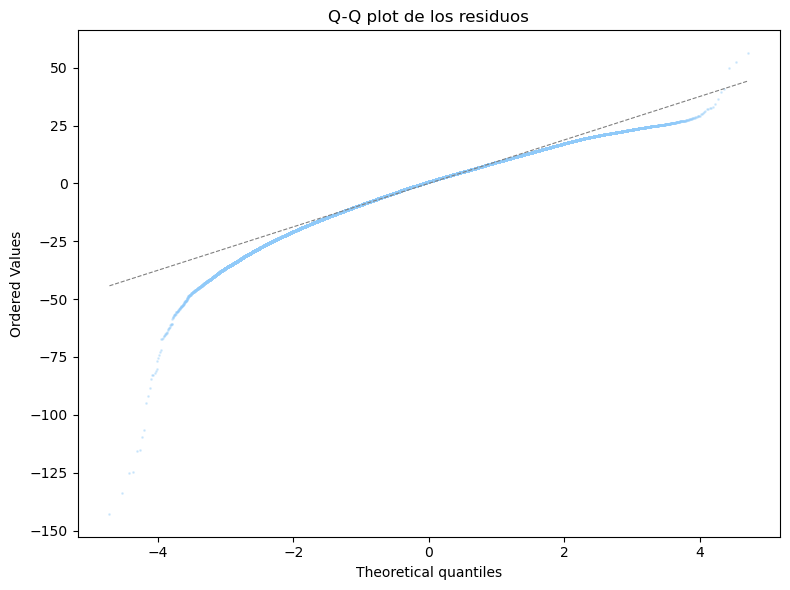

In [8]:
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
ax.set_facecolor("white")
stats.probplot(residuos, dist="norm", plot=ax)
ax.get_lines()[0].set(color="#90caf9", markersize=1, alpha=0.3)
ax.get_lines()[1].set(color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Q-Q plot de los residuos")
plt.tight_layout()
plt.show()

**Respuesta**

Lo que se esperaría es que la línea azul estuviera pegada a la línea diagonal negra, sin embargo, vemos que  precisamente en las colas, la línea azul se separa bastante. Lo que me indica que probablemente los errores no tienen una distribución normal. 

In [9]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = modelo.rsquared

print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.4f} minutos")

R²:   0.9427
RMSE: 9.4523 minutos


## Reporte

- Vemos que el 94.27% de la varianza en el retraso de llegada está siendo explicada por las variables incluidas.
- Se reporta que la diferencia entre los valores reales y los valores predichos fue de 9.45 minutos.
- Por las gráficas que relacionan los residuos con los valores predichos y el Q-Q plot de los residuos, me da a entender que los errores no están teniendo el comportamiento deseado y por lo tanto, parece indicar que hay que modificar el ajuste del modelo para poder obtener el comportamiento ideóneo. 

## Pronóstico de series de tiempo 

¿Cuántos vuelos habrá en los próximos meses?

### Preparación de los datos

In [11]:
!pip install statsforecast -q

In [12]:
import awswrangler as wr
import pandas as pd

# Leer datos desde Silver
df_monthly = wr.athena.read_sql_query(
    """
    SELECT month, SUM(total_flights) AS total_vuelos
    FROM flights_silver.flights_monthly
    GROUP BY month
    ORDER BY month
    """,
    database="flights_silver",
    ctas_approach=False
)

# StatsForecast requiere: unique_id, ds (fecha), y (variable objetivo)
df_monthly["unique_id"] = "vuelos_usa"
df_monthly["ds"] = pd.to_datetime(df_monthly["month"].apply(lambda x: f"2015-{x:02d}-01"))
df_monthly["y"] = df_monthly["total_vuelos"]

df_monthly = df_monthly[["unique_id", "ds", "y"]].sort_values("ds")
print(df_monthly)

     unique_id         ds       y
0   vuelos_usa 2015-01-01  469968
1   vuelos_usa 2015-02-01  429191
2   vuelos_usa 2015-03-01  504312
3   vuelos_usa 2015-04-01  485151
4   vuelos_usa 2015-05-01  496993
5   vuelos_usa 2015-06-01  503897
6   vuelos_usa 2015-07-01  520718
7   vuelos_usa 2015-08-01  510536
8   vuelos_usa 2015-09-01  464946
9   vuelos_usa 2015-10-01  486165
10  vuelos_usa 2015-11-01  467972
11  vuelos_usa 2015-12-01  479230


### Dividir en train y test - ajuste de modelos

In [13]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoARIMA, AutoTheta

# Split train/test — primeros 9 meses train, últimos 3 test
train = df_monthly[df_monthly["ds"] <= "2015-09-01"]
test  = df_monthly[df_monthly["ds"] > "2015-09-01"]

print(f"Train: {len(train)} meses")
print(f"Test:  {len(test)} meses")

# Inicializar StatsForecast
sf = StatsForecast(
    models=[
        AutoETS(season_length=12),
        AutoARIMA(season_length=12),
        AutoTheta(season_length=12)
    ],
    freq="MS"  # Monthly Start
)

# Entrenar
sf.fit(train)
print("✓ Modelos entrenados")

Train: 9 meses
Test:  3 meses
✓ Modelos entrenados


In [18]:
# Ver qué modelo seleccionó cada algoritmo
for model in sf.models:
    print(model)

AutoETS
AutoARIMA
AutoTheta


### Genera el pronóstico

In [15]:
# Generar pronóstico — 9 pasos con intervalos de confianza al 90%
forecast = sf.predict(h=9, level=[90])
print(forecast)

    unique_id         ds       AutoETS  AutoETS-lo-90  AutoETS-hi-90  \
0  vuelos_usa 2015-10-01  487319.90625   428025.15625     546614.625   
1  vuelos_usa 2015-11-01  487319.90625   428025.15625     546614.625   
2  vuelos_usa 2015-12-01  487319.90625   428025.15625     546614.625   
3  vuelos_usa 2016-01-01  487319.90625   428025.15625     546614.625   
4  vuelos_usa 2016-02-01  487319.90625   428025.15625     546614.625   
5  vuelos_usa 2016-03-01  487319.90625   428025.15625     546614.625   
6  vuelos_usa 2016-04-01  487319.90625   428025.15625     546614.625   
7  vuelos_usa 2016-05-01  487319.90625   428025.15625     546614.625   
8  vuelos_usa 2016-06-01  487319.90625   428025.15625     546614.625   

      AutoARIMA  AutoARIMA-lo-90  AutoARIMA-hi-90     AutoTheta  \
0  487301.34375     440427.09375      534175.5625  496523.56250   
1  487301.34375     440427.09375      534175.5625  496524.25000   
2  487301.34375     440427.09375      534175.5625  496524.96875   
3  487301.3

### Visualización 1 

Evaluación sobre el test set — grafica los 9 meses de entrenamiento (valores reales), los 3 meses del test set (valores reales), y el pronóstico de los tres modelos para esos 3 meses con bandas de confianza al 90%. ¿Qué modelo se acerca más a los valores reales?

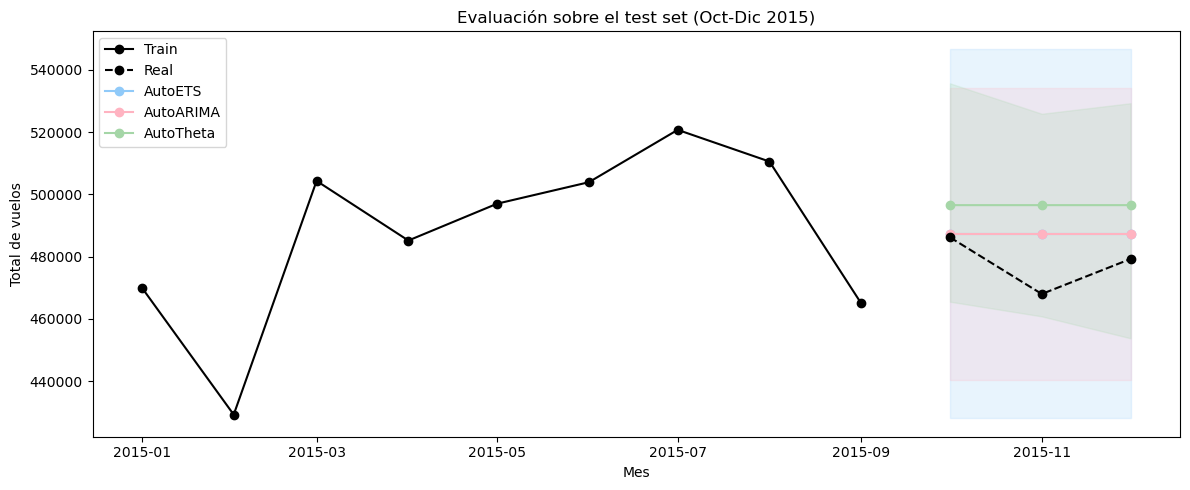

In [20]:
# Unir forecast con test set

df_test = test.merge(forecast[["unique_id", "ds", "AutoETS", "AutoARIMA", "AutoTheta",
                                "AutoETS-lo-90", "AutoETS-hi-90",
                                "AutoARIMA-lo-90", "AutoARIMA-hi-90",
                                "AutoTheta-lo-90", "AutoTheta-hi-90"]], 
                     on=["unique_id", "ds"], how="left")

fig, ax = plt.subplots(figsize=(12, 5), facecolor="white")
ax.set_facecolor("white")

# Train
ax.plot(train["ds"], train["y"], color="black", label="Train", marker="o")
# Test real
ax.plot(test["ds"], test["y"], color="black", linestyle="--", label="Real", marker="o", zorder=5)
# Pronósticos
ax.plot(df_test["ds"], df_test["AutoETS"],   color="#90caf9", label="AutoETS",   marker="o")
ax.plot(df_test["ds"], df_test["AutoARIMA"], color="#ffb3c1", label="AutoARIMA", marker="o")
ax.plot(df_test["ds"], df_test["AutoTheta"], color="#a5d6a7", label="AutoTheta", marker="o")
# Bandas de confianza
ax.fill_between(df_test["ds"], df_test["AutoETS-lo-90"],   df_test["AutoETS-hi-90"],   alpha=0.2, color="#90caf9")
ax.fill_between(df_test["ds"], df_test["AutoARIMA-lo-90"], df_test["AutoARIMA-hi-90"], alpha=0.2, color="#ffb3c1")
ax.fill_between(df_test["ds"], df_test["AutoTheta-lo-90"], df_test["AutoTheta-hi-90"], alpha=0.2, color="#a5d6a7")

ax.set_title("Evaluación sobre el test set (Oct-Dic 2015)")
ax.set_xlabel("Mes")
ax.set_ylabel("Total de vuelos")
ax.legend()
plt.tight_layout()
plt.show()

**Respuesta**

Se ven los valores reales de color negro y las predicciones de lado derecho. Parece que no están los resultados del modelo "AutoETS" pero en realidad está debajo de "AutoARIMA" porque tuvieron las mismas predicciones. 

Es díficil contestar cuál es el mejor modelo, porque en realidad tenemos muy pocos datos para obtener un mejor resultado. 

### Visualización 2

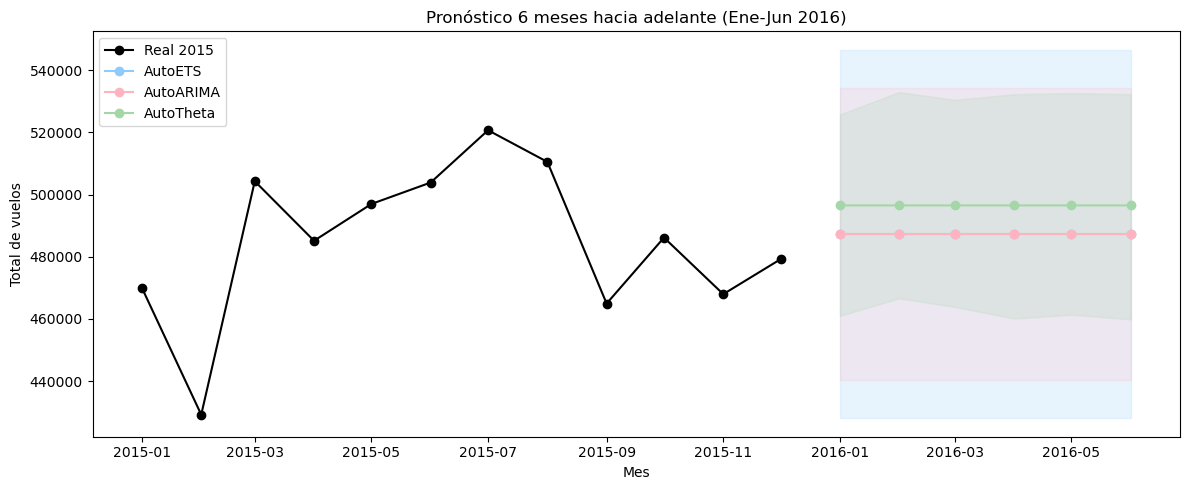

In [21]:
# Solo los 6 meses futuros (ene-jun 2016)
df_futuro = forecast[forecast["ds"] >= "2016-01-01"]

fig, ax = plt.subplots(figsize=(12, 5), facecolor="white")
ax.set_facecolor("white")

# Serie completa 2015
ax.plot(df_monthly["ds"], df_monthly["y"], color="black", label="Real 2015", marker="o")
# Pronósticos futuros
ax.plot(df_futuro["ds"], df_futuro["AutoETS"],   color="#90caf9", label="AutoETS",   marker="o")
ax.plot(df_futuro["ds"], df_futuro["AutoARIMA"], color="#ffb3c1", label="AutoARIMA", marker="o")
ax.plot(df_futuro["ds"], df_futuro["AutoTheta"], color="#a5d6a7", label="AutoTheta", marker="o")
# Bandas de confianza
ax.fill_between(df_futuro["ds"], df_futuro["AutoETS-lo-90"],   df_futuro["AutoETS-hi-90"],   alpha=0.2, color="#90caf9")
ax.fill_between(df_futuro["ds"], df_futuro["AutoARIMA-lo-90"], df_futuro["AutoARIMA-hi-90"], alpha=0.2, color="#ffb3c1")
ax.fill_between(df_futuro["ds"], df_futuro["AutoTheta-lo-90"], df_futuro["AutoTheta-hi-90"], alpha=0.2, color="#a5d6a7")

ax.set_title("Pronóstico 6 meses hacia adelante (Ene-Jun 2016)")
ax.set_xlabel("Mes")
ax.set_ylabel("Total de vuelos")
ax.legend()
plt.tight_layout()
plt.show()

### Visualización 3 

Comparación de MAE — tabla o gráfica de barras con el MAE de cada modelo calculado sobre los 3 meses del test set (en unidades de vuelos por mes).

In [22]:
from sklearn.metrics import mean_absolute_error

mae_ets   = mean_absolute_error(test["y"], df_test["AutoETS"])
mae_arima = mean_absolute_error(test["y"], df_test["AutoARIMA"])
mae_theta = mean_absolute_error(test["y"], df_test["AutoTheta"])

print(f"MAE AutoETS:   {mae_ets:,.0f} vuelos")
print(f"MAE AutoARIMA: {mae_arima:,.0f} vuelos")
print(f"MAE AutoTheta: {mae_theta:,.0f} vuelos")

MAE AutoETS:   9,531 vuelos
MAE AutoARIMA: 9,512 vuelos
MAE AutoTheta: 18,735 vuelos


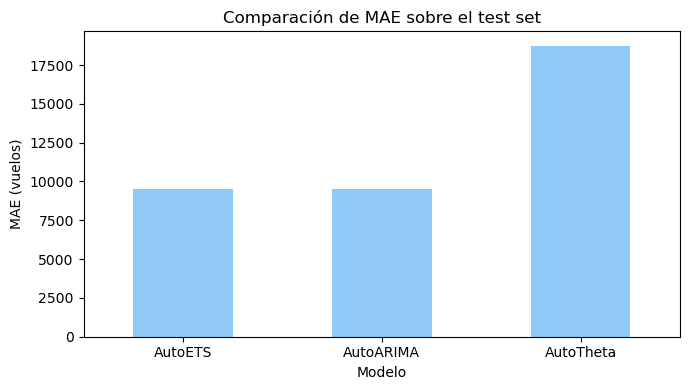

In [23]:
# Visualización 3 — Comparación de MAE
maes = {
    "AutoETS":   mae_ets,
    "AutoARIMA": mae_arima,
    "AutoTheta": mae_theta
}
df_mae = pd.DataFrame(list(maes.items()), columns=["modelo", "mae"])

fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
df_mae.plot(kind="bar", x="modelo", y="mae", legend=False, color="#90caf9", ax=ax)
ax.set_title("Comparación de MAE sobre el test set")
ax.set_xlabel("Modelo")
ax.set_ylabel("MAE (vuelos)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Respuesta**

El MAE es el promedio de las diferencias absolutas entre el valor predicho y el valor real. En este caso, encontramos que el modelo AutoARIMA se equivoca en promedio en 9,512 vuelos por mes. Al ser el valor más pequeño, parece ser el mejor modelo. Aunque lo digo con cautela, porque el modelo AutoETS tiene 9,531 vuelos, que también es un número bastante cercano. A diferencia del modelo AutoTheta que casi duplica el número. 